# Lab 2 – Exercise 2 (Online Retail)

**Student**: 22521609 – Phạm Duy Tuấn  

In [3]:
import itertools
from itertools import combinations
from collections import Counter

import pandas as pd

# mlxtend for Apriori, FP-Growth, and association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlxtend_apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## Question 1 – Load and clean the dataset

**Question 1 (from lab sheet)**  
*"Read the file `online_retail.xlsx` and display basic information about the dataset. Clean the data by: (1) removing rows with missing `CustomerID`, (2) keeping only rows where `Quantity > 0` and `UnitPrice > 0`."*

**Explanation**  
We will:
1. Load the Excel file into a pandas `DataFrame`.
2. Show basic information (head, shape, column types).
3. Apply the required cleaning steps and report how many rows remain after cleaning.

In [4]:
# Question 1: Read online retail data and clean it

file_path = "../Lab 2-20260331/Online Retail.xlsx"  # adjust path if needed

# Read the Excel file
retail_raw = pd.read_excel(file_path)

print("Raw data shape:", retail_raw.shape)
print("\nColumns:")
print(retail_raw.columns)

print("\nSample rows (head):")
display(retail_raw.head())

# Cleaning steps
retail_clean = retail_raw.copy()

# 1. Remove rows with missing CustomerID
retail_clean = retail_clean.dropna(subset=["CustomerID"])

# 2. Keep only rows where Quantity > 0 and UnitPrice > 0
retail_clean = retail_clean[(retail_clean["Quantity"] > 0) & (retail_clean["UnitPrice"] > 0)]

print("\nCleaned data shape:", retail_clean.shape)
display(retail_clean.head())

Raw data shape: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'], dtype='str')

Sample rows (head):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Cleaned data shape: (397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Question 2 – Build transaction list by InvoiceNo

**Question 2 (from lab sheet)**  
*"Convert the data into a transaction list, where each `InvoiceNo` is a transaction."*

**Explanation**  
We will group the cleaned data by `InvoiceNo`, and for each invoice collect the set/list of `Description` values (product names).  
The result is a Python list `transactions`, where each element is a list of items purchased in one invoice.

In [5]:
# Question 2: Convert cleaned data into transaction list (group by InvoiceNo)

# We assume 'Description' is the item name column
retail_clean["Description"] = retail_clean["Description"].astype(str).str.strip()

transactions = (
    retail_clean
    .groupby("InvoiceNo")["Description"]
    .apply(list)
    .tolist()
)

num_transactions = len(transactions)

print("Number of transactions (invoices):", num_transactions)
print("Example transaction (first one):")
print(transactions[0])

Number of transactions (invoices): 18532
Example transaction (first one):
['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'GLASS STAR FROSTED T-LIGHT HOLDER']


## Question 3 – Support function for an itemset

**Question 3 (from lab sheet)**  
*"Write a function to compute the support of an itemset."*

Support is defined as:

\[ support(X) = \frac{\text{number of transactions containing X}}{\text{total number of transactions}} \]

**Explanation**  
We implement a reusable function `compute_support(itemset, transactions)` that:
1. Iterates through all transactions.
2. Checks whether `itemset` is a subset of each transaction.
3. Counts how many transactions contain the itemset.
4. Returns the fraction (support) between 0 and 1.

In [6]:
# Question 3: function to compute support of an itemset

def compute_support(itemset, transactions):
    """Compute support of an itemset over the given transactions.

    Parameters
    ----------
    itemset : iterable of str
        Items X whose support we want to compute.
    transactions : list of list of str
        Transaction database.
    """
    itemset = set(itemset)
    num_transactions = len(transactions)

    if num_transactions == 0:
        return 0.0

    count = 0
    for t in transactions:
        if itemset.issubset(set(t)):
            count += 1

    return count / num_transactions


# Quick sanity check with the first transaction
example_itemset = transactions[0][:1]  # first item of first transaction
print("Example itemset:", example_itemset)
print("Support of example itemset:", compute_support(example_itemset, transactions))

Example itemset: ['WHITE HANGING HEART T-LIGHT HOLDER']
Support of example itemset: 0.10635657241528168


## Question 4 – Support of specific itemsets

**Question 4 (from lab sheet)**  
*"Compute the support of some specific itemsets (1-item and 2-item)."*

**Explanation**  
We reuse the `compute_support` function from Question 3 and test it on:
- Some **single items** (1-itemsets).  
- Some **pairs of items** (2-itemsets).

You can change the examples below to any items that seem interesting in the dataset.

In [7]:
# Question 4: compute support of some specific itemsets

# Pick a few popular items from the data (based on value_counts)
item_counts = retail_clean["Description"].value_counts()

print("Top 10 items by frequency:")
print(item_counts.head(10))

# Choose some example itemsets
item_1 = [item_counts.index[0]]  # most frequent item
item_2 = [item_counts.index[1]]  # second most frequent item
pair_1 = [item_counts.index[0], item_counts.index[1]]

print("\nExample 1-itemset:", item_1)
print("Support:", compute_support(item_1, transactions))

print("\nExample 1-itemset:", item_2)
print("Support:", compute_support(item_2, transactions))

print("\nExample 2-itemset:", pair_1)
print("Support:", compute_support(pair_1, transactions))

Top 10 items by frequency:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1723
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1396
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: count, dtype: int64

Example 1-itemset: ['WHITE HANGING HEART T-LIGHT HOLDER']
Support: 0.10635657241528168

Example 1-itemset: ['REGENCY CAKESTAND 3 TIER']
Support: 0.09189510036693287

Example 2-itemset: ['WHITE HANGING HEART T-LIGHT HOLDER', 'REGENCY CAKESTAND 3 TIER']
Support: 0.012626807684006043


## Question 5 – Frequent 1-itemsets with min_support = 0.02

**Question 5 (from lab sheet)**  
*"Find frequent 1-itemsets with `min_support = 0.02`."*

**Explanation**  
We iterate over all distinct items, compute the support of each 1-itemset, and keep only those with support ≥ 0.02.  
The result is stored in a dictionary `L1` mapping each frequent item (as a string) to its support.

In [8]:
# Question 5: find frequent 1-itemsets with min_support = 0.02

min_support = 0.02

# All unique items in the cleaned dataset
unique_items = retail_clean["Description"].unique()

support_1 = {}
for item in unique_items:
    sup = compute_support([item], transactions)
    if sup >= min_support:
        support_1[item] = sup

L1 = support_1

print(f"min_support = {min_support}")
print(f"Number of frequent 1-itemsets (L1): {len(L1)}")

# Show a sample of frequent 1-itemsets
for item, sup in list(L1.items())[:10]:
    print(f"{item:40s} support = {sup:.4f}")

min_support = 0.02
Number of frequent 1-itemsets (L1): 207
WHITE HANGING HEART T-LIGHT HOLDER       support = 0.1064
HAND WARMER UNION JACK                   support = 0.0238
ASSORTED COLOUR BIRD ORNAMENT            support = 0.0742
FELTCRAFT PRINCESS CHARLOTTE DOLL        support = 0.0216
HOME BUILDING BLOCK WORD                 support = 0.0373
LOVE BUILDING BLOCK WORD                 support = 0.0299
DOORMAT NEW ENGLAND                      support = 0.0287
JAM MAKING SET WITH JARS                 support = 0.0474
ALARM CLOCK BAKELIKE PINK                support = 0.0331
ALARM CLOCK BAKELIKE RED                 support = 0.0473


## Question 6 – Generate candidate 2-itemsets from L1

**Question 6 (from lab sheet)**  
*"Generate candidate 2-itemsets from frequent 1-itemsets."*

**Explanation**  
We take the items in `L1` and generate all 2-combinations using `itertools.combinations`.  
These pairs form the candidate 2-itemsets `C2` (we do not filter by support yet in this question).

In [9]:
# Question 6: generate candidate 2-itemsets from frequent 1-itemsets

items_L1 = list(L1.keys())
C2 = list(combinations(items_L1, 2))

print("Number of candidate 2-itemsets (C2):", len(C2))
print("Example candidates:")
for pair in C2[:10]:
    print(pair)

Number of candidate 2-itemsets (C2): 21321
Example candidates:
('WHITE HANGING HEART T-LIGHT HOLDER', 'HAND WARMER UNION JACK')
('WHITE HANGING HEART T-LIGHT HOLDER', 'ASSORTED COLOUR BIRD ORNAMENT')
('WHITE HANGING HEART T-LIGHT HOLDER', 'FELTCRAFT PRINCESS CHARLOTTE DOLL')
('WHITE HANGING HEART T-LIGHT HOLDER', 'HOME BUILDING BLOCK WORD')
('WHITE HANGING HEART T-LIGHT HOLDER', 'LOVE BUILDING BLOCK WORD')
('WHITE HANGING HEART T-LIGHT HOLDER', 'DOORMAT NEW ENGLAND')
('WHITE HANGING HEART T-LIGHT HOLDER', 'JAM MAKING SET WITH JARS')
('WHITE HANGING HEART T-LIGHT HOLDER', 'ALARM CLOCK BAKELIKE PINK')
('WHITE HANGING HEART T-LIGHT HOLDER', 'ALARM CLOCK BAKELIKE RED')
('WHITE HANGING HEART T-LIGHT HOLDER', 'ALARM CLOCK BAKELIKE GREEN')


## Question 7 – Frequent 2-itemsets

**Question 7 (from lab sheet)**  
*"Compute support and find frequent 2-itemsets."*

**Explanation**  
We reuse the `compute_support` function for each 2-itemset candidate in `C2`,  
then filter with the same `min_support` threshold (0.02) to build `L2`, the set of frequent 2-itemsets.

In [10]:
# Question 7: compute support and find frequent 2-itemsets

support_2 = {}
for pair in C2:
    sup = compute_support(pair, transactions)
    if sup >= min_support:
        support_2[pair] = sup

L2 = support_2

print(f"min_support = {min_support}")
print(f"Number of frequent 2-itemsets (L2): {len(L2)}")

for pair, sup in list(L2.items())[:10]:
    print(f"{pair} support = {sup:.4f}")

min_support = 0.02
Number of frequent 2-itemsets (L2): 35
('WHITE HANGING HEART T-LIGHT HOLDER', 'RED HANGING HEART T-LIGHT HOLDER') support = 0.0246
('ALARM CLOCK BAKELIKE PINK', 'ALARM CLOCK BAKELIKE RED') support = 0.0214
('ALARM CLOCK BAKELIKE RED', 'ALARM CLOCK BAKELIKE GREEN') support = 0.0286
('SPACEBOY LUNCH BOX', 'DOLLY GIRL LUNCH BOX') support = 0.0229
("PAPER CHAIN KIT 50'S CHRISTMAS", 'PAPER CHAIN KIT VINTAGE CHRISTMAS') support = 0.0243
('WOODEN PICTURE FRAME WHITE FINISH', 'WOODEN FRAME ANTIQUE WHITE') support = 0.0253
('JUMBO BAG PINK POLKADOT', 'JUMBO BAG RED RETROSPOT') support = 0.0295
('LUNCH BAG RED RETROSPOT', 'JUMBO BAG RED RETROSPOT') support = 0.0229
('LUNCH BAG RED RETROSPOT', 'LUNCH BAG SPACEBOY DESIGN') support = 0.0252
('LUNCH BAG RED RETROSPOT', 'LUNCH BAG WOODLAND') support = 0.0234


## Question 8 – Confidence of an association rule

**Question 8 (from lab sheet)**  
*"Write a function to compute the confidence of the rule \( X \to Y \). Use the formula: support(X ∪ Y) / support(X)."*

**Explanation**  
We implement `compute_confidence(X, Y, transactions)` that:
1. Treats `X` and `Y` as two itemsets.
2. Computes `support(X)` and `support(X ∪ Y)` using the `compute_support` function.
3. Returns `confidence = support(X ∪ Y) / support(X)` (or 0 if `support(X) = 0`).

In [11]:
# Question 8: function to compute confidence of X -> Y

def compute_confidence(X, Y, transactions):
    X = list(X)
    Y = list(Y)
    support_X = compute_support(X, transactions)
    if support_X == 0:
        return 0.0
    XY = list(set(X) | set(Y))
    support_XY = compute_support(XY, transactions)
    return support_XY / support_X


# Quick example using the two most frequent items
X_example = [item_counts.index[0]]
Y_example = [item_counts.index[1]]

print("Example rule:", X_example, "->", Y_example)
print("Confidence:", compute_confidence(X_example, Y_example, transactions))

Example rule: ['WHITE HANGING HEART T-LIGHT HOLDER'] -> ['REGENCY CAKESTAND 3 TIER']
Confidence: 0.1187214611872146


## Question 9 – Implement Apriori for all frequent itemsets

**Question 9 (from lab sheet)**  
*"Implement the Apriori algorithm to find all frequent itemsets."*

**Explanation**  
We adapt the Apriori implementation from Exercise 1 to this new transaction database:
- Input: `transactions`, `min_support`.
- Output: list `[L1, L2, ..., Lk]` of frequent itemsets at each level.

We will reuse the same `generate_candidates` and `prune_candidates` helper functions.

In [12]:
# Question 9: Implement the Apriori algorithm for the Online Retail dataset


def generate_candidates(prev_Lk):
    """Generate candidate (k+1)-itemsets from frequent k-itemsets (prev_Lk)."""
    prev_itemsets = list(prev_Lk.keys())
    k = len(prev_itemsets[0])  # size of itemsets in prev_Lk
    candidates = set()

    # Join step: combine itemsets that share first k-1 items
    for i in range(len(prev_itemsets)):
        for j in range(i + 1, len(prev_itemsets)):
            a = prev_itemsets[i]
            b = prev_itemsets[j]
            if a[: k - 1] == b[: k - 1]:  # they share prefix of length k-1
                candidate = tuple(sorted(set(a) | set(b)))
                if len(candidate) == k + 1:
                    candidates.add(candidate)

    return list(candidates)


def prune_candidates(candidates, prev_Lk):
    """Prune candidates whose any (k-1)-subset is not frequent."""
    prev_itemsets = set(prev_Lk.keys())
    if not candidates:
        return []
    k_plus_1 = len(candidates[0])
    k = k_plus_1 - 1

    pruned = []
    for cand in candidates:
        all_subsets_frequent = True
        for subset in combinations(cand, k):
            subset = tuple(sorted(subset))
            if subset not in prev_itemsets:
                all_subsets_frequent = False
                break
        if all_subsets_frequent:
            pruned.append(cand)
    return pruned


def apriori(transactions, min_support):
    """Apriori algorithm for the Online Retail transactions."""
    num_transactions = len(transactions)

    # Step 1: frequent 1-itemsets (L1)
    item_counter = Counter(item for t in transactions for item in t)
    L1 = {}
    for item, cnt in item_counter.items():
        sup = cnt / num_transactions
        if sup >= min_support:
            L1[(item,)] = sup

    L = []
    current_Lk = L1

    if not current_Lk:
        return L

    L.append(current_Lk)

    # Generate L2, L3, ...
    while True:
        # Generate candidates Ck from L(k-1)
        candidates = generate_candidates(current_Lk)
        candidates = prune_candidates(candidates, current_Lk)

        if not candidates:
            break

        # Count support for Ck
        support_k = {}
        for cand in candidates:
            sup = compute_support(cand, transactions)
            if sup >= min_support:
                support_k[cand] = sup

        if not support_k:
            break

        current_Lk = support_k
        L.append(current_Lk)

    return L


min_support_apriori = 0.02
L_levels = apriori(transactions, min_support=min_support_apriori)

print(f"Number of levels (L1, L2, ...): {len(L_levels)}")

Number of levels (L1, L2, ...): 3


## Question 10 – One-hot encoding for Online Retail

**Question 10 (from lab sheet)**  
*"Convert transaction data into one-hot encoding format."*

**Explanation**  
We again use `TransactionEncoder` to convert the transaction list to a boolean array, then wrap it into a `DataFrame` `df` that is suitable for `mlxtend`'s Apriori and FP-Growth implementations.

In [13]:
# Question 10: one-hot encode Online Retail transactions

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

print("Shape of one-hot encoded DataFrame:", df.shape)
display(df.head())

Shape of one-hot encoded DataFrame: (18532, 3866)


,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Question 11 – Run Apriori with mlxtend

**Question 11 (from lab sheet)**  
*"Use mlxtend to run Apriori."*

**Explanation**  
We apply `mlxtend.frequent_patterns.apriori` on the one-hot encoded `df` with a given `min_support` (e.g. 0.02), and inspect the resulting frequent itemsets.

In [14]:
# Question 11: run Apriori (mlxtend) on Online Retail data

min_support_mlxtend = 0.02

frequent_itemsets_ap = mlxtend_apriori(
    df,
    min_support=min_support_mlxtend,
    use_colnames=True
)

print("Number of frequent itemsets (mlxtend Apriori):", len(frequent_itemsets_ap))
frequent_itemsets_ap.sort_values(by="support", ascending=False).head()

Number of frequent itemsets (mlxtend Apriori): 243


,support,itemsets
192,0.106357,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
154,0.091895,frozenset({REGENCY CAKESTAND 3 TIER})
81,0.086337,frozenset({JUMBO BAG RED RETROSPOT})
124,0.074412,frozenset({PARTY BUNTING})
11,0.074196,frozenset({ASSORTED COLOUR BIRD ORNAMENT})


## Question 12 – Run FP-Growth with mlxtend

**Question 12 (from lab sheet)**  
*"Run FP-Growth on the dataset."*

**Explanation**  
We run `fpgrowth` on the same `df` with the same `min_support` value and compare the number of itemsets with Apriori.

In [15]:
# Question 12: run FP-Growth on Online Retail data

fp_itemsets = fpgrowth(
    df,
    min_support=min_support_mlxtend,
    use_colnames=True
)

print("Number of frequent itemsets (FP-Growth):", len(fp_itemsets))
fp_itemsets.sort_values(by="support", ascending=False).head()

Number of frequent itemsets (FP-Growth): 243


,support,itemsets
0,0.106357,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
120,0.091895,frozenset({REGENCY CAKESTAND 3 TIER})
52,0.086337,frozenset({JUMBO BAG RED RETROSPOT})
164,0.074412,frozenset({PARTY BUNTING})
2,0.074196,frozenset({ASSORTED COLOUR BIRD ORNAMENT})


## Question 13 – Generate association rules

**Question 13 (from lab sheet)**  
*"Generate association rules from frequent itemsets."*

**Explanation**  
We call `association_rules` on `fp_itemsets` (or `frequent_itemsets_ap`) using some metric, e.g. `confidence`, and a minimum threshold, e.g. `0.2`.  
The function returns a DataFrame where each row is an association rule.

In [16]:
# Question 13: generate association rules from frequent itemsets

rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=0.2
)

print("Number of generated rules:", len(rules))
rules.head()

Number of generated rules: 76


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED}),0.042575,0.047324,0.028599,0.671736,14.194548,1.0,0.026584,2.902169,0.970886,0.466549,0.655430,0.638035
1,frozenset({ALARM CLOCK BAKELIKE RED}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.047324,0.042575,0.028599,0.604333,14.194548,1.0,0.026584,2.419774,0.975725,0.466549,0.586738,0.638035
2,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE RED}),0.033078,0.047324,0.021368,0.646003,13.650778,1.0,0.019803,2.691201,0.958448,0.361974,0.628419,0.548771
3,frozenset({ALARM CLOCK BAKELIKE RED}),frozenset({ALARM CLOCK BAKELIKE PINK}),0.047324,0.033078,0.021368,0.451539,13.650778,1.0,0.019803,1.762974,0.972779,0.361974,0.432777,0.548771
4,frozenset({WOODEN FRAME ANTIQUE WHITE}),frozenset({WOODEN PICTURE FRAME WHITE FINISH}),0.043762,0.047270,0.025254,0.577065,12.207962,1.0,0.023185,2.252666,0.960102,0.383921,0.556082,0.555656


## Question 14 – Filter strong rules (confidence ≥ 0.7 and lift ≥ 1.2)

**Question 14 (from lab sheet)**  
*"Filter strong rules with: confidence ≥ 0.7 and lift ≥ 1.2."*

**Explanation**  
We filter the `rules` DataFrame using the two thresholds on the `confidence` and `lift` columns, and then inspect the resulting strong rules.

In [17]:
# Question 14: strong rules with confidence >= 0.7 and lift >= 1.2

strong_rules = rules[(rules["confidence"] >= 0.7) & (rules["lift"] >= 1.2)]

print("Number of strong rules (conf >= 0.7 and lift >= 1.2):", len(strong_rules))
strong_rules.sort_values(by=["confidence", "lift"], ascending=False).head(20)

Number of strong rules (conf >= 0.7 and lift >= 1.2): 8


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
58,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.023527,0.037287,0.021045,0.894495,23.989564,1.0,0.020167,9.124846,0.981405,0.529172,0.890409,0.729447
56,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.024822,0.042251,0.021045,0.847826,20.066300,1.0,0.019996,6.293778,0.974350,0.457210,0.841113,0.672955
53,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.030002,0.037287,0.024822,0.827338,22.188466,1.0,0.023703,5.575714,0.984468,0.584498,0.820651,0.746520
54,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.030002,0.042251,0.023527,0.784173,18.559754,1.0,0.022259,4.437569,0.975384,0.482835,0.774651,0.670503
48,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.037287,0.042251,0.029193,0.782923,18.530185,1.0,0.027617,4.412029,0.982675,0.579850,0.773347,0.736928
75,frozenset({GARDENERS KNEELING PAD CUP OF TEA}),frozenset({GARDENERS KNEELING PAD KEEP CALM}),0.034265,0.040794,0.024984,0.729134,17.873424,1.0,0.023586,3.541254,0.977547,0.498922,0.717614,0.670784
57,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.029193,0.030002,0.021045,0.720887,24.027846,1.0,0.020169,3.475290,0.987201,0.551627,0.712254,0.711163
60,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.030002,0.029193,0.021045,0.701439,24.027846,1.0,0.020169,3.251619,0.988024,0.551627,0.692461,0.711163


## Question 15 – Plot: min_support vs number of itemsets

**Question 15 (from lab sheet)**  
*"Plot a graph: min_support vs number of itemsets."*

**Explanation**  
We run Apriori with several `min_support` values, count the number of frequent itemsets for each one, and then visualize the relationship in a simple line plot.

This helps us understand how stricter support thresholds reduce the number of patterns.

Number of frequent itemsets for different min_support values:


,min_support,num_itemsets
0,0.02,243
1,0.03,91
2,0.05,17
3,0.07,5


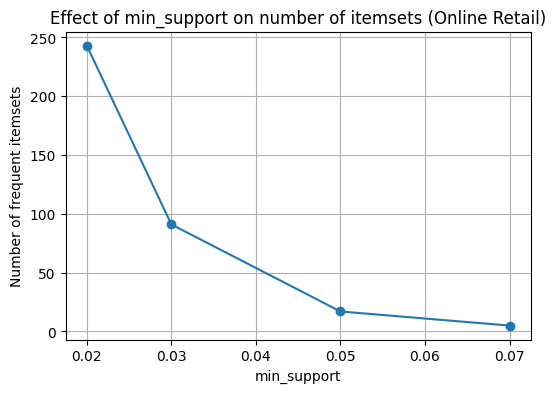

In [18]:
# Question 15: plot min_support vs number of itemsets

import matplotlib.pyplot as plt

supports = [0.02, 0.03, 0.05, 0.07]
counts = []

for s in supports:
    itemsets = mlxtend_apriori(df, min_support=s, use_colnames=True)
    counts.append(len(itemsets))

summary_df = pd.DataFrame({
    "min_support": supports,
    "num_itemsets": counts
})

print("Number of frequent itemsets for different min_support values:")
display(summary_df)

plt.figure(figsize=(6, 4))
plt.plot(summary_df["min_support"], summary_df["num_itemsets"], marker="o")
plt.xlabel("min_support")
plt.ylabel("Number of frequent itemsets")
plt.title("Effect of min_support on number of itemsets (Online Retail)")
plt.grid(True)
plt.show()